In [9]:
import imageio as iio
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D as ax3d
%matplotlib inline

C:\Users\miria\AppData\Local\Temp\ipykernel_4296\3123514955.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  imNp = iio.imread('001.png')
C:\Users\miria\AppData\Local\Temp\ipykernel_4296\3123514955.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  markImg = iio.imread('001_mark.png')


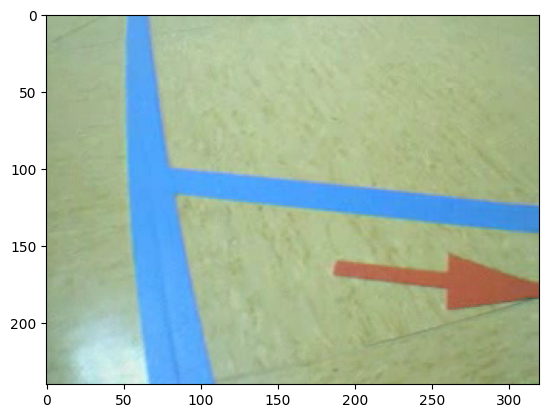

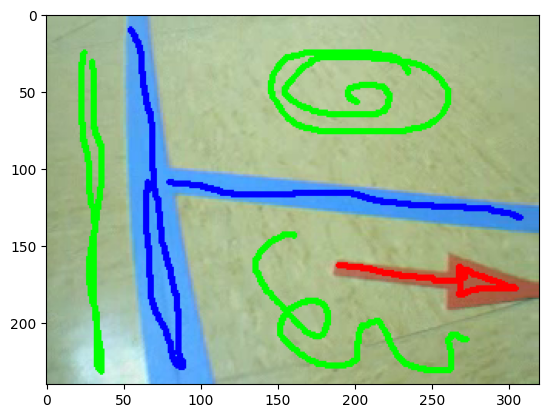

In [10]:
# Leo las imagenes de entrenamiento
imNp = iio.imread('001.png')
markImg = iio.imread('001_mark.png')
plt.imshow(imNp)
plt.show()
plt.imshow(markImg)
plt.show()

In [11]:
# Almaceno los valores RGB de 'imNp' que fueron marcados en 'markImg' en rojo verde y azul
mk = markImg[:, :, :3]

# Primero creo las máscaras booleanas para cada color
mask_marca = (mk[:,:,0] > 250) & (mk[:,:,1] < 5) & (mk[:,:,2] < 5)
mask_linea = (mk[:,:,2] > 250) & (mk[:,:,0] < 5) & (mk[:,:,1] < 5)
mask_fondo = (mk[:,:,1] > 250) & (mk[:,:,0] < 5) & (mk[:,:,2] < 5)

# Luego extraigo los datos de imNp usando las máscaras
data_marca = imNp[mask_marca]
data_fondo = imNp[mask_fondo]
data_linea = imNp[mask_linea]

Text(0.5, 0.92, 'Espacio RGB')

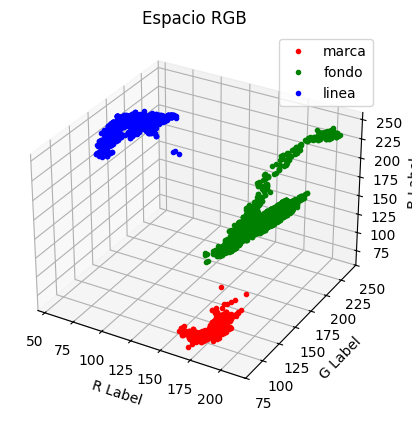

In [12]:
# Pinto los datos RGB
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(data_marca[:,0],data_marca[:,1],data_marca[:,2],'r.',label='marca')
ax.plot(data_fondo[:,0],data_fondo[:,1],data_fondo[:,2],'g.',label='fondo')
ax.plot(data_linea[:,0],data_linea[:,1],data_linea[:,2],'b.',label='linea')
ax.set_xlabel('R Label')
ax.set_ylabel('G Label')
ax.set_zlabel('B Label')
ax.legend()
plt.title('Espacio RGB')

In [13]:
# Ahora hago lo mismo con los datos normalizados segun la 'normalizacion rgb'
imrgbn = imNp / imNp.sum(axis=2, keepdims=True)
imNp=imrgbn

data_marca_n = imNp[mask_marca]
data_fondo_n = imNp[mask_fondo]
data_linea_n = imNp[mask_linea]

Text(0.5, 1.0, 'Espacio RGB normalizado')

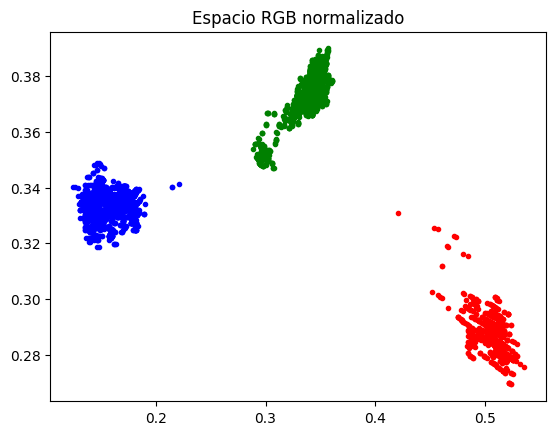

In [14]:
plt.figure()
plt.plot(data_marca_n[:,0],data_marca_n[:,1],'r.',label='marca')
plt.plot(data_fondo_n[:,0],data_fondo_n[:,1],'g.',label='fondo')
plt.plot(data_linea_n[:,0],data_linea_n[:,1],'b.',label='linea')
plt.title('Espacio RGB normalizado')

In [19]:
# Programa para leer un video y generar otro con los canales de color normalizados.
import cv2

video_entrada = 'videos/video2017-3.avi'
video_salida = 'videos/video2017-3_normalizado.avi'

cap = cv2.VideoCapture(video_entrada)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(video_salida, cv2.VideoWriter_fourcc(*'XVID'), fps, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_norm = frame / frame.sum(axis=2, keepdims=True)
    out.write((frame_norm * 255).astype('uint8'))

cap.release()
out.release()